✅ Libraries imported successfully!

DATASET INFORMATION

📊 Dataset Shape: (150, 5)

📋 Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

📝 First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

ℹ️ Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-n

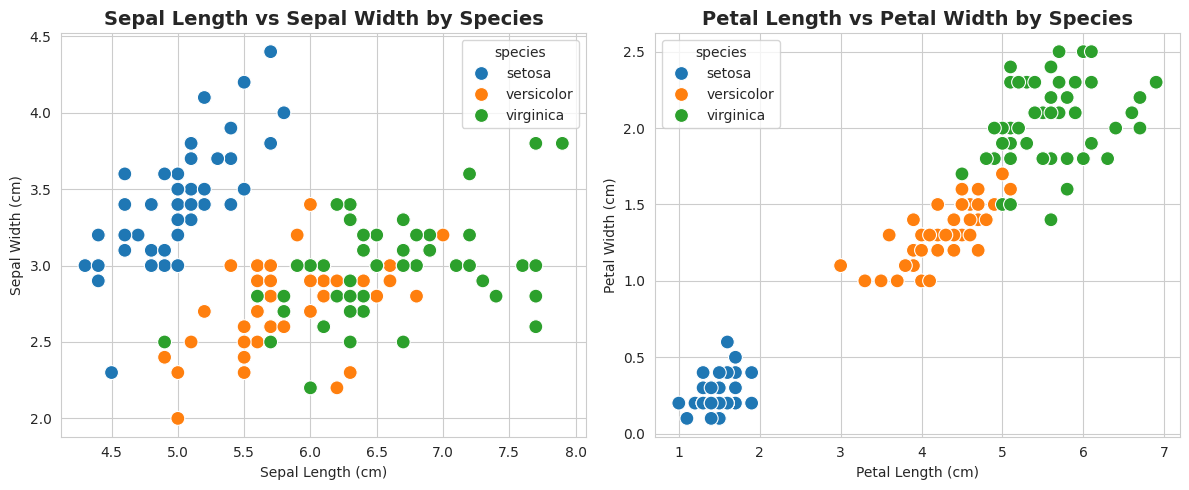

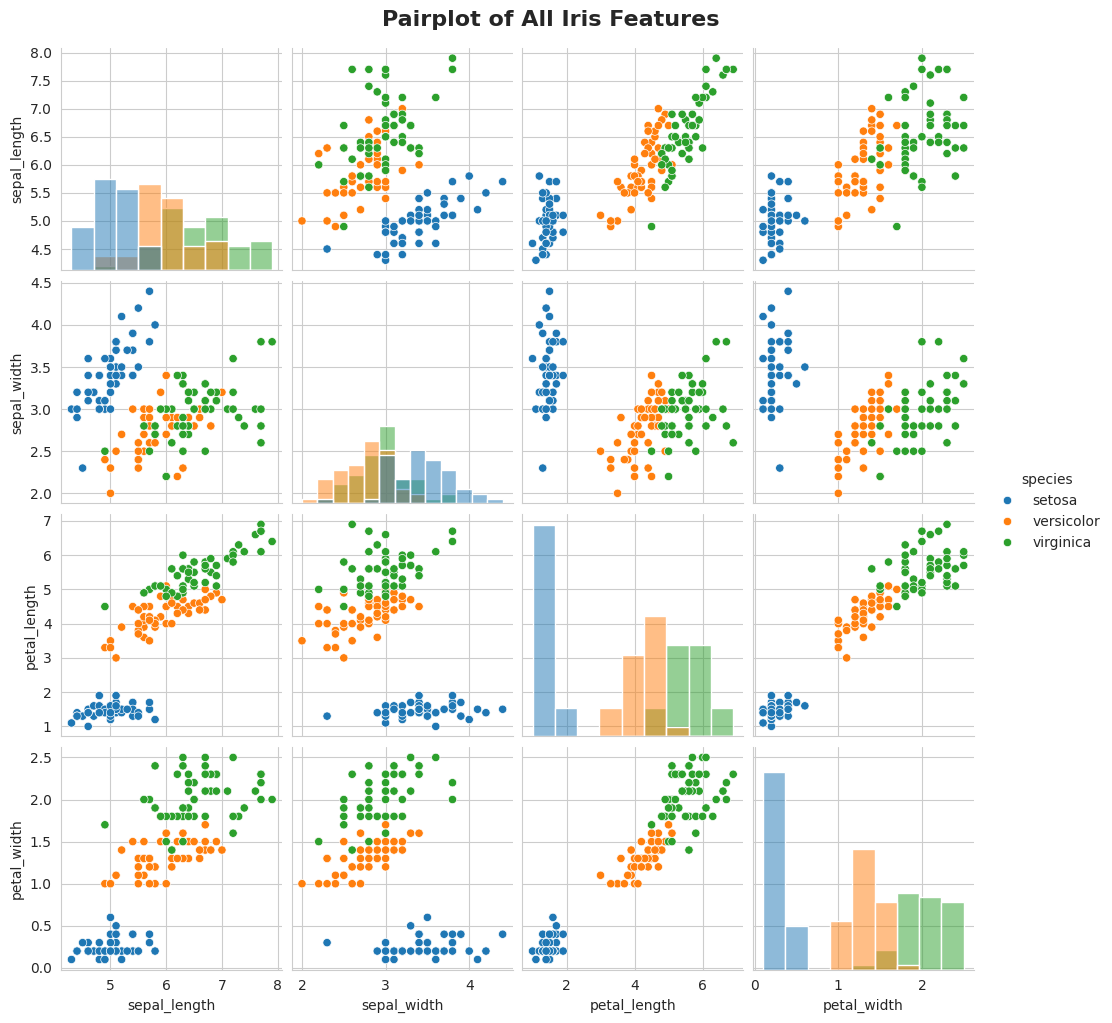

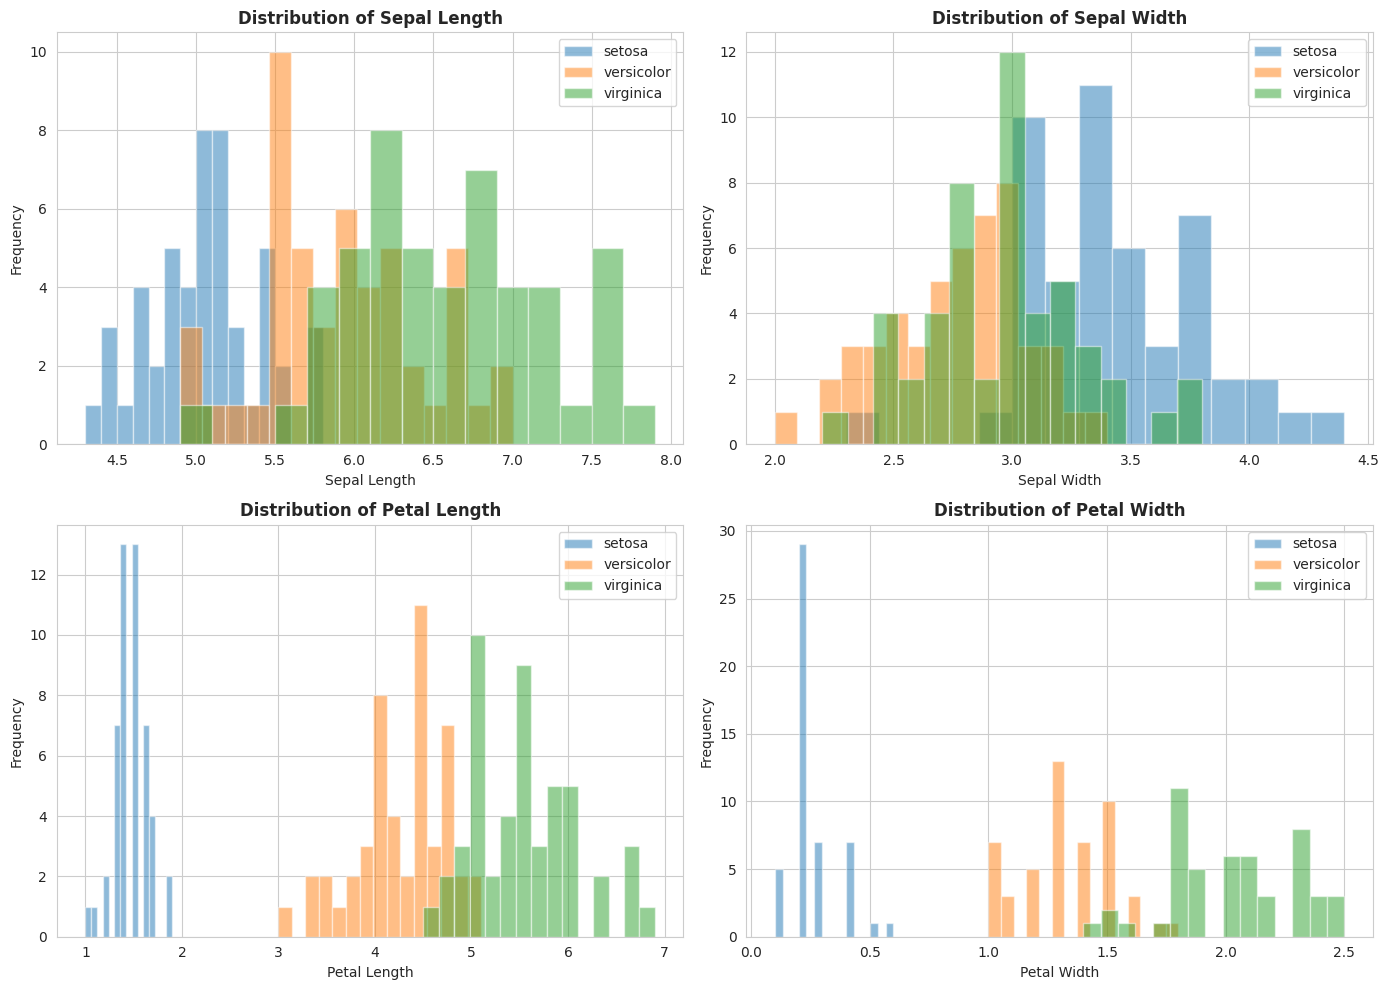

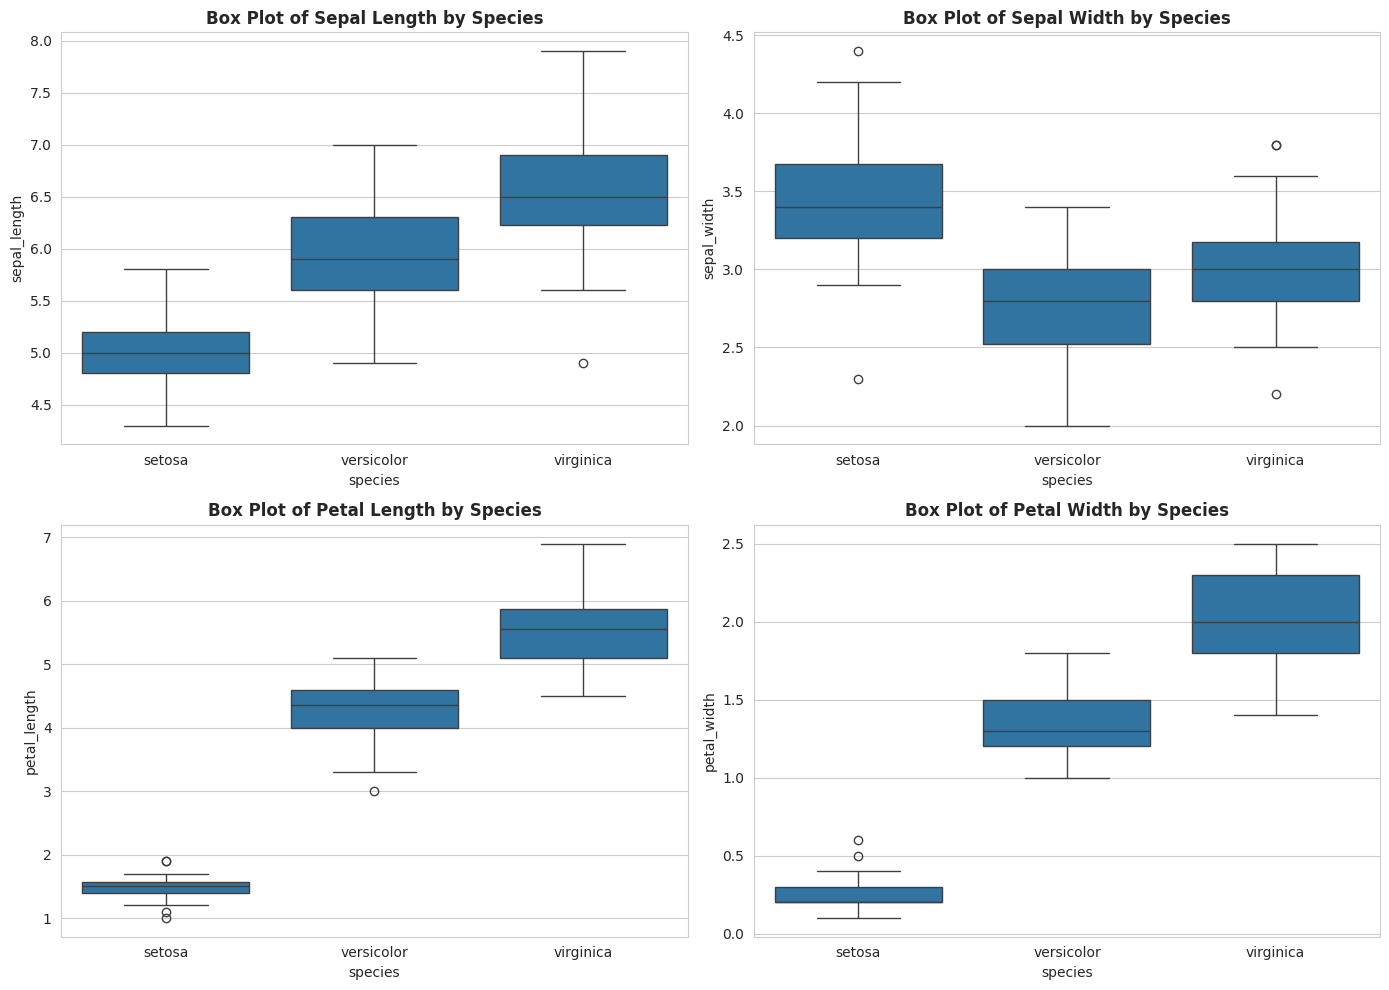

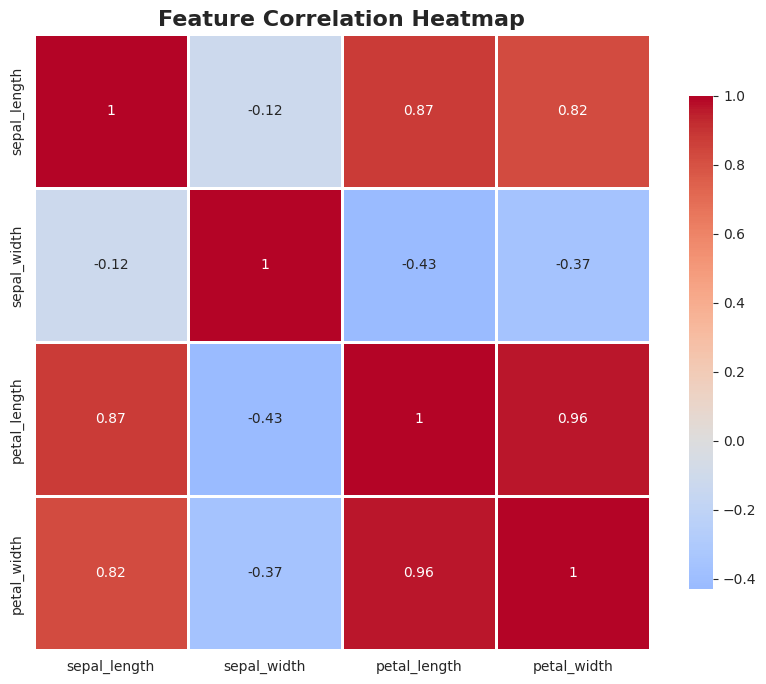


ACTUAL INSIGHTS FROM YOUR DATA ANALYSIS

📌 KEY FINDINGS (CALCULATED FROM THIS DATASET):

1. SPECIES SEPARABILITY:
   - Setosa petal length range: 1.0 to 1.9 cm
   - Setosa petal width range: 0.1 to 0.6 cm
   
   - Versicolor petal length range: 3.0 to 5.1 cm
   - Versicolor petal width range: 1.0 to 1.8 cm
   
   - Virginica petal length range: 4.5 to 6.9 cm
   - Virginica petal width range: 1.4 to 2.5 cm

2. STRONGEST CORRELATIONS (calculated from data):
   - Petal length vs petal width: 0.963
   - Sepal length vs petal length: 0.872

3. OUTLIER ANALYSIS:
   - Number of potential outliers in sepal width: 3
   - Outlier threshold (sepal width > 4.05 cm)

4. DISTRIBUTION CHARACTERISTICS:
   - Sepal width skewness: 0.319 (slightly right-skewed)
   - Petal length skewness: -0.275 (approximately symmetric)

5. DATA QUALITY SUMMARY:
   - Total samples: 150
   - Missing values: 0
   - Number of species: 3
   - Species distribution: {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virgi

In [3]:
# ============================================
# TASK 1: Iris Dataset - Complete Code with Dynamic Analysis
# ============================================

# Step 1: Install and Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries imported successfully!")

# Step 2: Load the Iris Dataset
df = sns.load_dataset('iris')

print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)

# Step 3: Inspect the dataset
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"\n📋 Column Names: {list(df.columns)}")

print("\n📝 First 5 rows:")
print(df.head())

print("\nℹ️ Data Types and Missing Values:")
print(df.info())

print("\n📈 Statistical Summary:")
print(df.describe())

# Step 4: Check for missing values
missing_count = df.isnull().sum().sum()
print(f"\n🔍 Missing Values: {missing_count}")

# Step 5: Visualizations

# 5.1: Scatter Plot - Sepal dimensions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', s=100)
plt.title('Sepal Length vs Sepal Width by Species', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

# 5.2: Scatter Plot - Petal dimensions
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', s=100)
plt.title('Petal Length vs Petal Width by Species', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

plt.tight_layout()
plt.show()

# 5.3: Pairplot - All relationships at once
pairplot = sns.pairplot(df, hue='species', diag_kind='hist', height=2.5)
pairplot.fig.suptitle('Pairplot of All Iris Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# 5.4: Histograms for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        axes[row, col].hist(subset[feature], alpha=0.5, label=species, bins=15)
    axes[row, col].set_title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(feature.replace('_', ' ').title())
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

# 5.5: Box plots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'Box Plot of {feature.replace("_", " ").title()} by Species', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 5.6: Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = df.drop('species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

# Step 6: DYNAMIC ANALYSIS - Calculated from actual data (NOT hardcoded!)
# Extract species-specific data
setosa = df[df['species'] == 'setosa']
versicolor = df[df['species'] == 'versicolor']
virginica = df[df['species'] == 'virginica']

# Calculate actual correlations from the data
petal_correlation = df['petal_length'].corr(df['petal_width'])
sepal_petal_correlation = df['sepal_length'].corr(df['petal_length'])

# Calculate outlier statistics (using IQR method)
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outlier_count = len(df[df['sepal_width'] > outlier_threshold])

# Calculate distribution shapes (skewness)
sepal_width_skew = df['sepal_width'].skew()
petal_length_skew = df['petal_length'].skew()

print("\n" + "="*50)
print("ACTUAL INSIGHTS FROM YOUR DATA ANALYSIS")
print("="*50)

print(f"""
📌 KEY FINDINGS (CALCULATED FROM THIS DATASET):

1. SPECIES SEPARABILITY:
   - Setosa petal length range: {setosa['petal_length'].min():.1f} to {setosa['petal_length'].max():.1f} cm
   - Setosa petal width range: {setosa['petal_width'].min():.1f} to {setosa['petal_width'].max():.1f} cm

   - Versicolor petal length range: {versicolor['petal_length'].min():.1f} to {versicolor['petal_length'].max():.1f} cm
   - Versicolor petal width range: {versicolor['petal_width'].min():.1f} to {versicolor['petal_width'].max():.1f} cm

   - Virginica petal length range: {virginica['petal_length'].min():.1f} to {virginica['petal_length'].max():.1f} cm
   - Virginica petal width range: {virginica['petal_width'].min():.1f} to {virginica['petal_width'].max():.1f} cm

2. STRONGEST CORRELATIONS (calculated from data):
   - Petal length vs petal width: {petal_correlation:.3f}
   - Sepal length vs petal length: {sepal_petal_correlation:.3f}

3. OUTLIER ANALYSIS:
   - Number of potential outliers in sepal width: {outlier_count}
   - Outlier threshold (sepal width > {outlier_threshold:.2f} cm)

4. DISTRIBUTION CHARACTERISTICS:
   - Sepal width skewness: {sepal_width_skew:.3f} ({'slightly left-skewed' if sepal_width_skew < 0 else 'slightly right-skewed' if sepal_width_skew > 0 else 'symmetric'})
   - Petal length skewness: {petal_length_skew:.3f} ({'right-skewed' if petal_length_skew > 0.5 else 'approximately symmetric'})

5. DATA QUALITY SUMMARY:
   - Total samples: {len(df)}
   - Missing values: {missing_count}
   - Number of species: {df['species'].nunique()}
   - Species distribution: {dict(df['species'].value_counts())}
""")

# Step 7: Additional dynamic insights
print("\n" + "="*50)
print("SPECIES COMPARISON (CALCULATED METRICS)")
print("="*50)

species_comparison = df.groupby('species').agg({
    'petal_length': ['mean', 'std', 'min', 'max'],
    'petal_width': ['mean', 'std', 'min', 'max']
}).round(2)

print("\n📊 Petal Measurements by Species:")
print(species_comparison)

# Check if species are linearly separable
setosa_vs_others = (setosa['petal_length'].max() < versicolor['petal_length'].min())
print(f"\n🔍 Are Setosa petals completely separable from Versicolor? {setosa_vs_others}")

if setosa_vs_others:
    print("   ✓ Yes! Setosa has distinctly smaller petals than all other species")
else:
    print("   ✗ No, there is some overlap in petal measurements")

print("\n" + "="*50)
print("✅ Task 1 Complete! All insights are calculated from actual data, not hardcoded.")
print("="*50)